In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import TS6 as ts6

from ipywidgets import interact

the current calibration sheet is 241228. 
Selecting a more appropriate date for you is recommended.
Run set_cali_date(date).


In [2]:
%matplotlib widget

In [3]:
pd.set_option('display.max_rows', 120)

In [4]:
ts6.set_cali_date(250130)

calibration log successfully updated!!
now use 250130 calibration sheet.


In [5]:
offset_start = 0
offset_stop = 30

In [6]:
data = ts6.read_data(250130, 3)

using local file.


In [7]:
sheet_name_cali = '250130'
sheet_id_cali = '1izM2mY1kjGAxIqMIXwhyzw1iuuMF3k5VXFJqi9Sy2U4'
url_cali = f'https://docs.google.com/spreadsheets/d/%s/gviz/tq?tqx=out:csv&sheet=%s' %(sheet_id_cali, sheet_name_cali)

cali_data = pd.read_csv(url_cali) # the calibration file.
cali_data['dtacq_num'] = cali_data['dtacq_num'].ffill() #filling the missing data

In [8]:
data = data - data[0, :]

# clearing the offset noise
calidata = data - data[offset_start:offset_stop, :].mean(axis=0)

# take out the calibration data where digitizer is 39, ok is not 0 and direction is z
cali_data_alivez = cali_data.query('dtacq_num==39')

# take out the alive channels, remember to minus 1 because in python columns starts from 0
# calidata = data[:, cali_data_alivez['dtacq_ch'].values-1]

# NS and polarity calibration
calidata = calidata * cali_data_alivez['RC/NS'].values[None, :]
calidata = calidata * cali_data_alivez['polarity'].values[None, :]

interactive(children=(IntSlider(value=5, description='page', max=11), Output()), _dom_classes=('widget-interac…

<function __main__.update(page)>

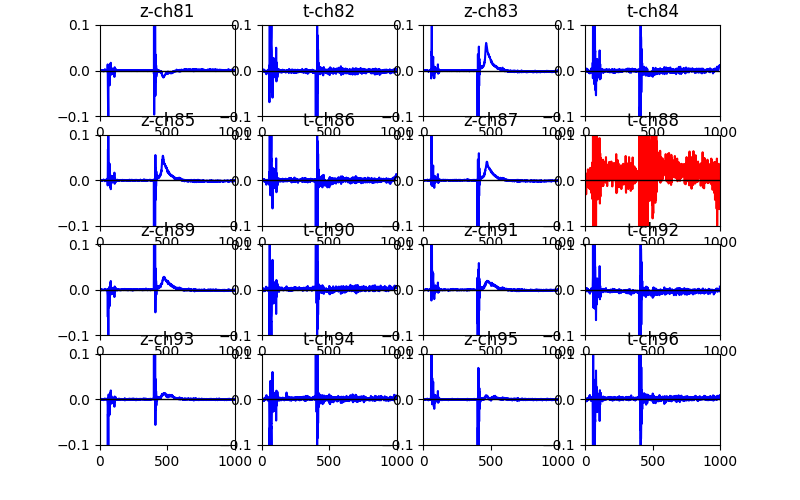

In [9]:
# plt.close()

fig, ax = plt.subplots(4, 4, figsize=(8, 5))
fig.subplots_adjust(top=0.95)

start=0
stop=1000

t=np.arange(start, stop)

for i in range(4):
    for j in range(4):
        ax[i, j].plot(t, calidata[start:stop, i*4+j])
        ax[i, j].set_title('%s-ch%i' %(cali_data.loc[i*4+j, 'direction'], i*4+j-1))
        # ax[i, j].set_ylim(-0.03, 0.03)
        ax[i, j].hlines(0, 0, 1000, 'k', lw=1)
        ax[i, j].set_xlim([start, stop])
        ax[i, j].set_ylim(-0.1, 0.1)

def update(page):
    for i in range(4):
        for j in range(4):
            line = ax[i, j].get_lines()[0]
            line.set_ydata(calidata[start:stop, i*4+j+page*16])
            ax[i, j].set_title('%s-ch%i' %(cali_data.loc[i*4+j+page*16, 'direction'], i*4+j+page*16+1))
            # ax[i, j].relim()
            # ax[i, j].autoscale()

            if cali_data.loc[i*4+j+page*16, 'ok'] == 1:
                line.set_color('b')
            elif cali_data.loc[i*4+j+page*16, 'ok'] == 0:
                line.set_color('r')
                
            # ax[i, j].set_xlim([start, stop])
                

interact(update, page=(0, 11))

In [10]:
plt.close()

In [14]:
cali_data.query('dtacq_ch==23')['ok']

22    1
Name: ok, dtype: int64